Online Fraud Detection System

EXPLORATORY DATA ANALYSIS
Data source: generated synthetic demonstration data
Rows: 10,000 | Columns: 8

Column types:
amount                   float64
transaction_hour           int64
merchant_category         object
distance_from_home_km    float64
is_international           int64
device_trust_score       float64
previous_chargebacks       int64
is_fraud                   int64

Missing values by column:
amount                   0
transaction_hour         0
merchant_category        0
distance_from_home_km    0
is_international         0
device_trust_score       0
previous_chargebacks     0
is_fraud                 0

Numeric summary:
          amount  transaction_hour  distance_from_home_km  is_international  device_trust_score  previous_chargebacks   is_fraud
count  10000.000         10000.000              10000.000         10000.000           10000.000             10000.000  10000.000
mean      69.982            11.628                 18.180          

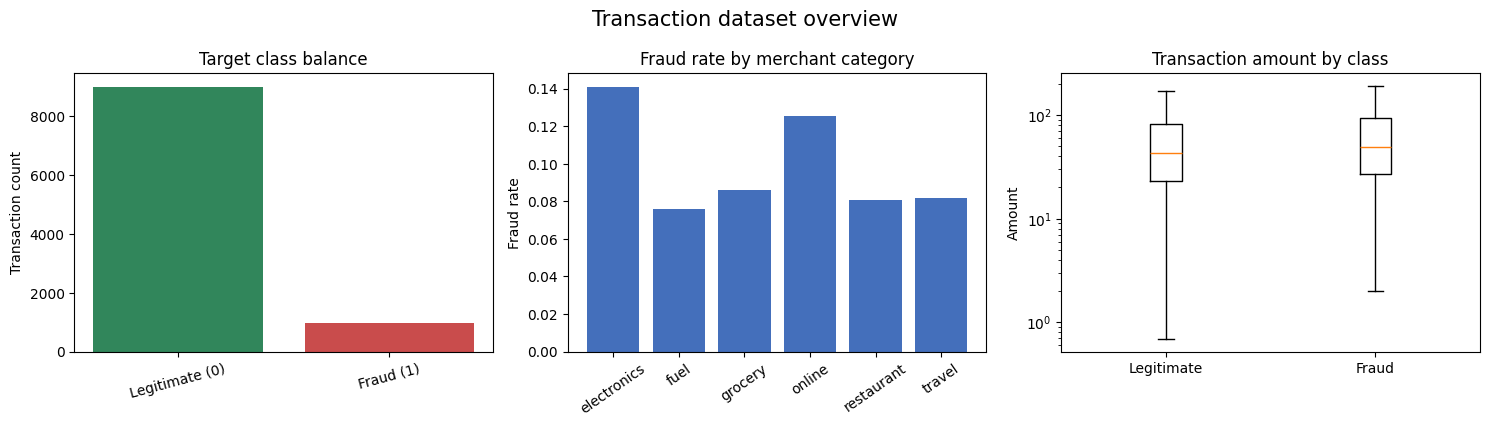


RANDOM FOREST HOLD-OUT EVALUATION
{
  "accuracy": 0.8845,
  "balanced_accuracy": 0.6172,
  "precision_fraud": 0.3836,
  "recall_fraud": 0.2843,
  "f1_fraud": 0.3265,
  "roc_auc": 0.7543,
  "average_precision": 0.2913,
  "brier_score": 0.0794,
  "review_threshold": 0.3,
  "test_rows": 2000,
  "fraud_rate_in_dataset": 0.0983,
  "confusion_matrix_labels": [
    "Legitimate (0)",
    "Fraud (1)"
  ]
}

Confusion matrix (rows=actual, columns=predicted; [0, 1]):
[[1713   90]
 [ 141   56]]

Classification report:
              precision    recall  f1-score   support

  Legitimate       0.92      0.95      0.94      1803
       Fraud       0.38      0.28      0.33       197

    accuracy                           0.88      2000
   macro avg       0.65      0.62      0.63      2000
weighted avg       0.87      0.88      0.88      2000



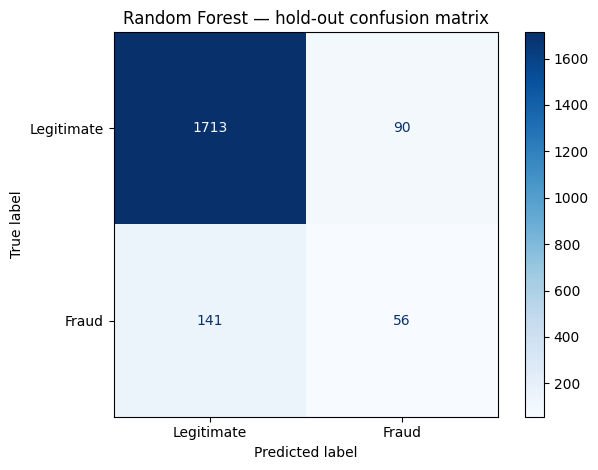


Selected model features and Random Forest importance:
                      feature  importance
              numeric__amount    0.495205
    numeric__transaction_hour    0.259058
numeric__previous_chargebacks    0.135651
    numeric__is_international    0.110085


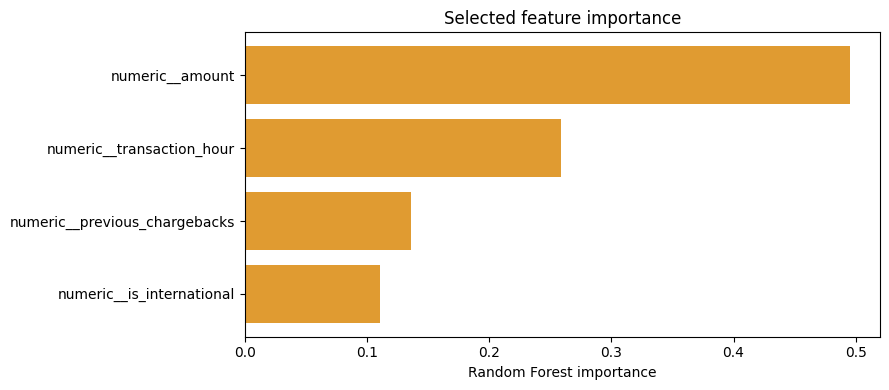


Saved trained model: /content/online_fraud_random_forest.joblib
Model file: online_fraud_random_forest.joblib

SAMPLE TRANSACTION PREDICTIONS
Example A — lower-risk profile: Legitimate (estimated risk 3.71%)
Example B — elevated-risk profile: Fraud (estimated risk 55.19%)
Starting notebook-native predictions (no Flask API or JSON fetch).


Output()

HTML(value='<h3>Dashboard and transaction history</h3>')

Output()

In [7]:
"""ONLINE FRAUD DETECTION SYSTEM

Beginner-friendly, single-file project for Google Colab or a local Python session.
It creates a realistic demonstration dataset by default, explores and preprocesses
it, performs train-only feature selection, trains and evaluates a Random Forest,
saves the fitted model with Joblib, and tests sample transactions. In Google Colab,
the prediction dashboard runs directly in the notebook and calls the trained model
without a browser-to-server JSON request. Locally, the project starts a Flask UI.
The scoring tree preserves the training class rate (no class reweighting), and
hold-out Brier score is reported to audit probability quality.
Each checked transaction receives a unique ID, risk percentage and band, and a
fraud alert when flagged. History is saved to CSV and can be downloaded.

Run in Google Colab with:
    # Upload this .py file to Colab, then run:
    %run /content/online_fraud_detection_system.py

Run locally with:
    python online_fraud_detection_system.py

The default labels are synthetic demonstration labels, not real-world fraud facts.
Risk bands use <30% = Low, 30% to <70% = Medium, and >=70% = High. The fraud
alert threshold is configured by FRAUD_REVIEW_THRESHOLD (default 0.30).
Do not use this educational demo as the sole basis for financial decisions.
"""
from __future__ import annotations

# Install missing libraries automatically. This keeps the project convenient in
# a fresh Colab runtime while avoiding unnecessary package reinstalls.
import importlib.util
import subprocess
import sys


def ensure_dependencies() -> None:
    """Install only packages that are not already importable."""
    required = {
        "numpy": "numpy",
        "pandas": "pandas",
        "sklearn": "scikit-learn",
        "matplotlib": "matplotlib",
        "flask": "Flask",
        "joblib": "joblib",
        "ipywidgets": "ipywidgets",
    }
    missing = [package for module, package in required.items()
               if importlib.util.find_spec(module) is None]
    if missing:
        print("Installing missing packages:", ", ".join(missing))
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "--quiet", *missing]
        )


ensure_dependencies()

import csv
import io
import json
import logging
import math
import os
import uuid
from datetime import datetime, timezone
from html import escape
import threading
from pathlib import Path
from typing import Any

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from flask import Flask, jsonify, render_template_string, request, send_file
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectFromModel
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# -----------------------------------------------------------------------------
# 1. Project settings (edit these options if you want to use your own CSV)
# -----------------------------------------------------------------------------
PROJECT_TITLE = "Online Fraud Detection System"
RANDOM_STATE = 42
TARGET = "is_fraud"  # 0 = legitimate transaction, 1 = fraud
FEATURES = [
    "amount",
    "transaction_hour",
    "merchant_category",
    "distance_from_home_km",
    "is_international",
    "device_trust_score",
    "previous_chargebacks",
]
NUMERIC_FEATURES = [
    "amount",
    "transaction_hour",
    "distance_from_home_km",
    "is_international",
    "device_trust_score",
    "previous_chargebacks",
]
CATEGORICAL_FEATURES = ["merchant_category"]
INTEGER_FEATURES = {"transaction_hour", "is_international", "previous_chargebacks"}
HISTORY_COLUMNS = [
    "transaction_id", "timestamp_utc", "prediction", "is_fraud",
    "fraud_probability", "risk_percent", "risk_level", "fraud_alert",
    "alert_message", *FEATURES,
]
REVIEW_THRESHOLD = float(os.getenv("FRAUD_REVIEW_THRESHOLD", "0.30"))

# Default: immediately runnable, interpretable demonstration data.
# Set USE_COLAB_FILE_UPLOAD=True to upload a CSV inside Google Colab, or set the
# FRAUD_DATA_CSV environment variable to the path of a CSV file.
USE_COLAB_FILE_UPLOAD = False
CSV_PATH = os.getenv("FRAUD_DATA_CSV", "").strip() or None
SYNTHETIC_ROWS = 10_000
MODEL_FILENAME = "online_fraud_random_forest.joblib"
HISTORY_FILENAME = "online_fraud_transaction_history.csv"
LOW_RISK_CUTOFF = 30.0
HIGH_RISK_CUTOFF = 70.0

LOGGER = logging.getLogger(PROJECT_TITLE.replace(" ", "_"))


# -----------------------------------------------------------------------------
# 2. Dataset generation, loading, and validation
# -----------------------------------------------------------------------------
def create_sample_dataset(
    n_rows: int = SYNTHETIC_ROWS,
    seed: int = RANDOM_STATE,
) -> pd.DataFrame:
    """Make reproducible, human-readable transactions for an end-to-end demo.

    These simulated labels are created from a transparent risk recipe plus
    randomness. They are useful for learning the workflow, not for claiming
    real-world model quality.
    """
    if not isinstance(n_rows, int) or n_rows < 100:
        raise ValueError("n_rows must be an integer of at least 100.")

    rng = np.random.default_rng(seed)
    categories = np.array(
        ["grocery", "electronics", "travel", "online", "fuel", "restaurant"]
    )
    frame = pd.DataFrame(
        {
            "amount": np.round(rng.lognormal(mean=3.8, sigma=0.95, size=n_rows), 2),
            "transaction_hour": rng.integers(0, 24, size=n_rows),
            "merchant_category": rng.choice(categories, size=n_rows),
            "distance_from_home_km": np.round(
                rng.exponential(scale=18, size=n_rows), 2
            ),
            "is_international": rng.binomial(1, 0.10, size=n_rows),
            "device_trust_score": np.round(rng.beta(5, 2, size=n_rows), 3),
            "previous_chargebacks": rng.poisson(0.16, size=n_rows),
        }
    )

    late_hour = frame["transaction_hour"].isin([0, 1, 2, 3, 4, 23])
    elevated_category = frame["merchant_category"].isin(["electronics", "online"])
    # Synthetic probability recipe; it is not a rule for real transactions.
    log_odds = (
        -4.4
        + 0.22 * np.log1p(frame["amount"])
        + 1.25 * (frame["amount"] > 250)
        + 1.10 * late_hour
        + 1.30 * (frame["distance_from_home_km"] > 80)
        + 1.35 * frame["is_international"]
        + 1.50 * (frame["device_trust_score"] < 0.30)
        + 1.25 * (frame["previous_chargebacks"] > 0)
        + 0.70 * elevated_category
    )
    probabilities = 1 / (1 + np.exp(-log_odds))
    frame[TARGET] = rng.binomial(1, probabilities).astype(int)
    return frame


def _normalise_csv_columns(frame: pd.DataFrame) -> pd.DataFrame:
    """Normalize common target aliases and whitespace in user CSV headers."""
    renamed: dict[Any, str] = {}
    for column in frame.columns:
        clean = str(column).strip().lower().replace(" ", "_")
        renamed[column] = clean
    frame = frame.rename(columns=renamed)
    target_aliases = {"class", "fraud_label", "fraud", "target", "isfraud"}
    for alias in target_aliases:
        if alias in frame.columns and TARGET not in frame.columns:
            frame = frame.rename(columns={alias: TARGET})
    return frame


def validate_feature_ranges(
    frame: pd.DataFrame,
    *,
    allow_missing: bool,
) -> None:
    """Check values, finite numbers, ranges, and whole-number requirements."""
    rules = {
        "amount": (0, math.inf),
        "transaction_hour": (0, 23),
        "distance_from_home_km": (0, math.inf),
        "is_international": (0, 1),
        "device_trust_score": (0, 1),
        "previous_chargebacks": (0, math.inf),
    }
    for column, (minimum, maximum) in rules.items():
        values = frame[column]
        if not allow_missing and values.isna().any():
            raise ValueError(f"{column} must be a valid number.")
        present = values.dropna().astype(float)
        if not np.isfinite(present.to_numpy()).all():
            raise ValueError(f"{column} must contain finite numbers.")
        if ((present < minimum) | (present > maximum)).any():
            if math.isinf(maximum):
                raise ValueError(f"{column} must be at least {minimum}.")
            raise ValueError(f"{column} must be between {minimum} and {maximum}.")
        if column in INTEGER_FEATURES and not np.isclose(
            present.to_numpy(), np.round(present.to_numpy())
        ).all():
            raise ValueError(f"{column} must be a whole number.")


def load_dataset(csv_path: str | os.PathLike[str] | None = None) -> tuple[pd.DataFrame, str]:
    """Load a validated CSV or fall back to the built-in synthetic sample."""
    if csv_path is None:
        frame = create_sample_dataset()
        source = "generated synthetic demonstration data"
    else:
        path = Path(csv_path).expanduser()
        if not path.is_file():
            raise FileNotFoundError(f"CSV file was not found: {path}")
        try:
            frame = pd.read_csv(path)
        except (OSError, pd.errors.ParserError, UnicodeDecodeError) as exc:
            raise ValueError(f"Could not read CSV file: {exc}") from exc
        if frame.empty:
            raise ValueError("The CSV file has no rows.")
        frame = _normalise_csv_columns(frame)
        missing = sorted(set(FEATURES + [TARGET]) - set(frame.columns))
        if missing:
            raise ValueError(
                "CSV is missing required columns: " + ", ".join(missing)
            )
        frame = frame[FEATURES + [TARGET]].copy()
        for column in NUMERIC_FEATURES:
            original = frame[column]
            converted = pd.to_numeric(original, errors="coerce")
            invalid_text = original.notna() & converted.isna()
            if invalid_text.any():
                raise ValueError(f"CSV column {column} contains non-numeric text.")
            frame[column] = converted
        labels = pd.to_numeric(frame[TARGET], errors="coerce")
        if labels.isna().any() or not labels.isin([0, 1]).all():
            raise ValueError(
                f"{TARGET} must contain only non-blank 0 (legitimate) or 1 (fraud) labels."
            )
        frame[TARGET] = labels.astype(int)
        frame["merchant_category"] = (
            frame["merchant_category"].fillna("unknown").astype(str).str.strip().str.lower()
        )
        frame.loc[frame["merchant_category"].eq(""), "merchant_category"] = "unknown"
        validate_feature_ranges(frame, allow_missing=True)
        source = str(path.resolve())

    counts = frame[TARGET].value_counts()
    if set(counts.index.astype(int)) != {0, 1}:
        raise ValueError("Training data must include both classes: 0 and 1.")
    if int(counts.min()) < 5:
        raise ValueError("At least five rows of each class are required for training.")
    return frame, source


def choose_training_csv() -> str | None:
    """Resolve an explicit path or show Colab's optional upload prompt."""
    if CSV_PATH:
        return CSV_PATH
    if USE_COLAB_FILE_UPLOAD:
        try:
            from google.colab import files
        except ImportError as exc:
            raise RuntimeError(
                "Set USE_COLAB_FILE_UPLOAD=False outside Google Colab, or provide FRAUD_DATA_CSV."
            ) from exc
        uploaded = files.upload()
        if not uploaded:
            raise RuntimeError("No CSV was uploaded. Run again and choose a file.")
        filename = next(iter(uploaded))
        if not filename.lower().endswith(".csv"):
            raise ValueError("Please upload a .csv file.")
        return str(Path.cwd() / filename)
    return None


# -----------------------------------------------------------------------------
# 3. Exploratory data analysis
# -----------------------------------------------------------------------------
def run_eda(frame: pd.DataFrame, source: str) -> None:
    """Print basic data-quality summaries and display three useful EDA charts."""
    print("\n" + "=" * 72)
    print("EXPLORATORY DATA ANALYSIS")
    print("=" * 72)
    print(f"Data source: {source}")
    print(f"Rows: {len(frame):,} | Columns: {len(frame.columns)}")
    print("\nColumn types:")
    print(frame.dtypes.to_string())
    print("\nMissing values by column:")
    missing = frame.isna().sum().sort_values(ascending=False)
    print(missing.to_string())
    print("\nNumeric summary:")
    print(frame[NUMERIC_FEATURES + [TARGET]].describe().round(3).to_string())
    print("\nClass counts (0=Legitimate, 1=Fraud):")
    print(frame[TARGET].value_counts().sort_index().to_string())
    print(f"Fraud prevalence: {frame[TARGET].mean():.2%}")

    class_counts = frame[TARGET].value_counts().reindex([0, 1], fill_value=0)
    fraud_by_category = frame.groupby("merchant_category", dropna=False)[TARGET].mean()
    amount_by_class = [
        frame.loc[frame[TARGET] == label, "amount"].dropna().to_numpy()
        for label in [0, 1]
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
    axes[0].bar(["Legitimate (0)", "Fraud (1)"], class_counts.values,
                color=["#31865b", "#c94c4c"])
    axes[0].set_title("Target class balance")
    axes[0].set_ylabel("Transaction count")
    axes[0].tick_params(axis="x", rotation=15)

    axes[1].bar(fraud_by_category.index.astype(str), fraud_by_category.values,
                color="#446fbb")
    axes[1].set_title("Fraud rate by merchant category")
    axes[1].set_ylabel("Fraud rate")
    axes[1].tick_params(axis="x", rotation=35)

    axes[2].boxplot(amount_by_class, tick_labels=["Legitimate", "Fraud"],
                    showfliers=False)
    axes[2].set_title("Transaction amount by class")
    axes[2].set_ylabel("Amount")
    axes[2].set_yscale("log")

    fig.suptitle("Transaction dataset overview", fontsize=15)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


# -----------------------------------------------------------------------------
# 4. Preprocessing, feature selection, train/test split, and model evaluation
# -----------------------------------------------------------------------------
def build_model_pipeline() -> Pipeline:
    """Create leakage-safe preprocessing, train-only selection, and scoring forest."""
    numeric_pipeline = Pipeline(
        [("imputer", SimpleImputer(strategy="median", keep_empty_features=True))]
    )
    categorical_pipeline = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )
    preprocessing = ColumnTransformer(
        [
            ("numeric", numeric_pipeline, NUMERIC_FEATURES),
            ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
        ],
        remainder="drop",
    )
    selector_model = DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )
    final_forest = RandomForestClassifier(
        n_estimators=180,
        max_depth=12,
        min_samples_leaf=8,
        # Do not rebalance the final classifier: class weights distort the
        # probabilities that are displayed as transaction risk percentages.
        class_weight=None,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    return Pipeline(
        [
            ("preprocessing", preprocessing),
            ("feature_selection", SelectFromModel(selector_model, threshold="mean")),
            ("classifier", final_forest),
        ]
    )


def fraud_probabilities(model: Pipeline, features: pd.DataFrame) -> np.ndarray:
    """Return P(class=1) by label, rather than assuming a probability column."""
    class_labels = np.asarray(model.classes_)
    fraud_indices = np.flatnonzero(class_labels == 1)
    if len(fraud_indices) != 1:
        raise RuntimeError("The trained model does not contain a fraud class labelled 1.")
    probabilities = np.asarray(model.predict_proba(features))
    if probabilities.ndim != 2 or probabilities.shape[1] != len(class_labels):
        raise RuntimeError("The model returned probabilities with an unexpected shape.")
    return probabilities[:, int(fraud_indices[0])]


def train_and_evaluate(
    frame: pd.DataFrame,
) -> tuple[Pipeline, dict[str, Any], pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Split data, fit the pipeline on training rows, and report hold-out metrics."""
    features = frame[FEATURES].copy()
    labels = frame[TARGET].astype(int)
    X_train, X_test, y_train, y_test = train_test_split(
        features,
        labels,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=labels,
    )
    model = build_model_pipeline()
    model.fit(X_train, y_train)

    probability = fraud_probabilities(model, X_test)
    predicted = (probability >= REVIEW_THRESHOLD).astype(int)
    matrix = confusion_matrix(y_test, predicted, labels=[0, 1])
    report_text = classification_report(
        y_test,
        predicted,
        labels=[0, 1],
        target_names=["Legitimate", "Fraud"],
        zero_division=0,
    )
    metrics = {
        "accuracy": round(float(accuracy_score(y_test, predicted)), 4),
        "balanced_accuracy": round(float(balanced_accuracy_score(y_test, predicted)), 4),
        "precision_fraud": round(float(precision_score(y_test, predicted, zero_division=0)), 4),
        "recall_fraud": round(float(recall_score(y_test, predicted, zero_division=0)), 4),
        "f1_fraud": round(float(f1_score(y_test, predicted, zero_division=0)), 4),
        "roc_auc": round(float(roc_auc_score(y_test, probability)), 4),
        "average_precision": round(float(average_precision_score(y_test, probability)), 4),
        "brier_score": round(float(brier_score_loss(y_test, probability)), 4),
        "review_threshold": REVIEW_THRESHOLD,
        "test_rows": int(len(y_test)),
        "fraud_rate_in_dataset": round(float(labels.mean()), 4),
        "confusion_matrix_labels": ["Legitimate (0)", "Fraud (1)"],
        "confusion_matrix": matrix.tolist(),
        "classification_report": report_text,
    }

    print("\n" + "=" * 72)
    print("RANDOM FOREST HOLD-OUT EVALUATION")
    print("=" * 72)
    print(json.dumps({k: v for k, v in metrics.items()
                      if k not in {"classification_report", "confusion_matrix"}}, indent=2))
    print("\nConfusion matrix (rows=actual, columns=predicted; [0, 1]):")
    print(matrix)
    print("\nClassification report:")
    print(report_text)

    display = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=["Legitimate", "Fraud"],
    )
    display.plot(cmap="Blues", values_format="d")
    plt.title("Random Forest — hold-out confusion matrix")
    plt.tight_layout()
    plt.show()
    plt.close()

    return model, metrics, X_train, X_test, y_train, y_test


def get_selected_feature_importance(model: Pipeline) -> pd.DataFrame:
    """Map final Random Forest importances to selected encoded feature names."""
    preprocessing = model.named_steps["preprocessing"]
    selector = model.named_steps["feature_selection"]
    tree = model.named_steps["classifier"]
    feature_names = np.asarray(preprocessing.get_feature_names_out(), dtype=str)
    selected_names = feature_names[selector.get_support()]
    importances = tree.feature_importances_
    if len(selected_names) != len(importances):
        raise RuntimeError("Could not align selected feature names with model importances.")
    result = pd.DataFrame({"feature": selected_names, "importance": importances})
    result = result.sort_values("importance", ascending=False, ignore_index=True)
    return result


def show_feature_importance(model: Pipeline, top_n: int = 15) -> pd.DataFrame:
    """Display the features selected by the training-only tree selector."""
    importance = get_selected_feature_importance(model)
    print("\nSelected model features and Random Forest importance:")
    print(importance.head(top_n).to_string(index=False))
    visible = importance.head(top_n).sort_values("importance")
    fig, ax = plt.subplots(figsize=(9, max(4, 0.32 * len(visible))))
    ax.barh(visible["feature"], visible["importance"], color="#e09b31")
    ax.set_title("Selected feature importance")
    ax.set_xlabel("Random Forest importance")
    fig.tight_layout()
    plt.show()
    plt.close(fig)
    return importance


# -----------------------------------------------------------------------------
# 5. Prediction validation, model persistence, and sample transactions
# -----------------------------------------------------------------------------
def parse_number(value: Any, field: str) -> float:
    """Convert one web/API value to a finite float, rejecting bools and blanks."""
    if isinstance(value, bool) or value is None:
        raise ValueError(f"{field} must be a valid number.")
    if isinstance(value, str) and not value.strip():
        raise ValueError(f"{field} must be a valid number.")
    try:
        number = float(value)
    except (TypeError, ValueError) as exc:
        raise ValueError(f"{field} must be a valid number.") from exc
    if not math.isfinite(number):
        raise ValueError(f"{field} must be finite.")
    return number


def prepare_user_transaction(payload: Any) -> pd.DataFrame:
    """Validate required fields and return a single-row model input frame."""
    if not isinstance(payload, dict):
        raise ValueError("Request body must be a JSON object.")
    missing = [name for name in FEATURES if name not in payload]
    if missing:
        raise ValueError("Missing required fields: " + ", ".join(missing))

    row: dict[str, Any] = {}
    for field in NUMERIC_FEATURES:
        row[field] = parse_number(payload[field], field)
    category = payload["merchant_category"]
    if not isinstance(category, str) or not category.strip():
        raise ValueError("merchant_category must be non-empty text.")
    category = category.strip().lower()
    if len(category) > 80:
        raise ValueError("merchant_category must be 80 characters or fewer.")
    row["merchant_category"] = category
    frame = pd.DataFrame([row], columns=FEATURES)
    validate_feature_ranges(frame, allow_missing=False)
    return frame


def risk_level_for_percent(risk_percent: float) -> str:
    """Map a fraud probability to a simple, configurable display band."""
    if risk_percent < LOW_RISK_CUTOFF:
        return "Low Risk"
    if risk_percent < HIGH_RISK_CUTOFF:
        return "Medium Risk"
    return "High Risk"


def predict_transaction(
    model: Pipeline,
    payload: Any,
    threshold: float = REVIEW_THRESHOLD,
) -> dict[str, Any]:
    """Return a unique ID, prediction, fraud-risk score, band, and alert."""
    frame = prepare_user_transaction(payload)
    fraud_probability = float(fraud_probabilities(model, frame)[0])
    is_fraud = fraud_probability >= threshold
    risk_percent = round(fraud_probability * 100, 2)
    return {
        "transaction_id": "TXN-" + uuid.uuid4().hex.upper(),
        "timestamp_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "prediction": "Fraud" if is_fraud else "Legitimate",
        "is_fraud": bool(is_fraud),
        "fraud_probability": round(fraud_probability, 4),
        "risk_percent": risk_percent,
        "risk_level": risk_level_for_percent(risk_percent),
        "fraud_alert": bool(is_fraud),
        "alert_message": (
            "FRAUD ALERT: This transaction was flagged for review."
            if is_fraud
            else ""
        ),
        "threshold": threshold,
        "message": (
            "The model flagged this transaction for review."
            if is_fraud
            else "The model classified this transaction as legitimate."
        ),
        "disclaimer": "Educational demo only; a model prediction is not proof of fraud.",
    }


def make_history_record(payload: Any, result: dict[str, Any]) -> dict[str, Any]:
    """Combine validated transaction inputs with their prediction for history."""
    frame = prepare_user_transaction(payload)
    record: dict[str, Any] = {
        "transaction_id": result["transaction_id"],
        "timestamp_utc": result["timestamp_utc"],
        "prediction": result["prediction"],
        "is_fraud": result["is_fraud"],
        "fraud_probability": result["fraud_probability"],
        "risk_percent": result["risk_percent"],
        "risk_level": result["risk_level"],
        "fraud_alert": result["fraud_alert"],
        "alert_message": result["alert_message"],
    }
    for field in FEATURES:
        value = frame.iloc[0][field]
        if field in INTEGER_FEATURES:
            record[field] = int(value)
        elif field in NUMERIC_FEATURES:
            record[field] = float(value)
        else:
            record[field] = str(value)
    return record


def persist_history_record(
    history: list[dict[str, Any]], lock: Any, history_path: Path,
    record: dict[str, Any],
) -> None:
    """Add one prediction to runtime history and append it to the CSV file."""
    with lock:
        history.append(record)
        try:
            needs_header = not history_path.exists() or history_path.stat().st_size == 0
            with history_path.open("a", newline="", encoding="utf-8") as history_file:
                writer = csv.DictWriter(history_file, fieldnames=HISTORY_COLUMNS)
                if needs_header:
                    writer.writeheader()
                writer.writerow(record)
        except OSError:
            LOGGER.exception("Could not persist transaction history to %s", history_path)


def save_model(model: Pipeline, metrics: dict[str, Any]) -> Path:
    """Persist the trained pipeline, metrics, schema, and threshold with Joblib."""
    model_path = Path(MODEL_FILENAME).resolve()
    artifact = {
        "model": model,
        "features": FEATURES,
        "target": TARGET,
        "threshold": REVIEW_THRESHOLD,
        "metrics": metrics,
        "project_title": PROJECT_TITLE,
    }
    joblib.dump(artifact, model_path)
    print(f"\nSaved trained model: {model_path}")
    return model_path


SAMPLE_TRANSACTIONS = {
    "Example A — lower-risk profile": {
        "amount": 45.50,
        "transaction_hour": 14,
        "merchant_category": "grocery",
        "distance_from_home_km": 3.0,
        "is_international": 0,
        "device_trust_score": 0.92,
        "previous_chargebacks": 0,
    },
    "Example B — elevated-risk profile": {
        "amount": 920.00,
        "transaction_hour": 2,
        "merchant_category": "electronics",
        "distance_from_home_km": 140.0,
        "is_international": 1,
        "device_trust_score": 0.12,
        "previous_chargebacks": 2,
    },
}


def test_sample_transactions(model: Pipeline) -> None:
    """Print example classifications to confirm the prediction code is callable."""
    print("\n" + "=" * 72)
    print("SAMPLE TRANSACTION PREDICTIONS")
    print("=" * 72)
    for name, transaction in SAMPLE_TRANSACTIONS.items():
        result = predict_transaction(model, transaction)
        print(
            f"{name}: {result['prediction']} "
            f"(estimated risk {result['risk_percent']:.2f}%)"
        )


# -----------------------------------------------------------------------------
# 6. Flask front end: HTML, CSS, JavaScript, API, and health route
# -----------------------------------------------------------------------------
WEB_PAGE = r"""<!doctype html>
<html lang="en">
<head>
  <meta charset="utf-8">
  <meta name="viewport" content="width=device-width, initial-scale=1">
  <title>Online Fraud Detection Dashboard</title>
  <style>
    :root { --ink:#182538; --muted:#58677b; --line:#d5deea; --blue:#185da3;
      --bg:#f2f6fb; --white:#fff; --green:#23824c; --red:#c43d3d; }
    * { box-sizing:border-box; }
    body { margin:0; padding:26px 14px; background:var(--bg); color:var(--ink);
      font:15px/1.5 system-ui,-apple-system,"Segoe UI",sans-serif; }
    main { max-width:1120px; margin:0 auto; }
    h1 { margin:0 0 5px; font-size:clamp(1.7rem,4vw,2.25rem); }
    h2 { margin:0 0 14px; font-size:1.2rem; }
    .intro,.muted,.note { color:var(--muted); }
    .panel { margin-top:18px; padding:clamp(18px,3vw,28px); background:var(--white);
      border:1px solid var(--line); border-radius:15px; box-shadow:0 10px 28px #14243a0d; }
    .cards { display:grid; grid-template-columns:repeat(4,minmax(0,1fr)); gap:12px; }
    .metric { padding:15px; border:1px solid var(--line); border-radius:11px; background:#fbfdff; }
    .metric-label { color:var(--muted); font-size:.88rem; }
    .metric-value { display:block; margin-top:4px; font-size:1.7rem; font-weight:750; }
    .charts { display:grid; grid-template-columns:1fr 1fr; gap:24px; margin-top:18px; }
    .bar-row { display:grid; grid-template-columns:100px 1fr 42px; align-items:center; gap:9px; margin:12px 0; }
    .track { height:16px; background:#e9eef5; border-radius:99px; overflow:hidden; }
    .bar { height:100%; width:0; transition:width .25s; }
    .bar.fraud { background:var(--red); } .bar.legit { background:var(--green); }
    .grid { display:grid; grid-template-columns:repeat(2,minmax(0,1fr)); gap:14px; margin-top:18px; }
    label { display:block; font-weight:650; font-size:.92rem; }
    input { width:100%; margin-top:5px; padding:10px 11px; border:1px solid #b9c6d6;
      border-radius:8px; background:#fff; color:var(--ink); font:inherit; }
    input:focus,button:focus { outline:3px solid #185da344; outline-offset:2px; }
    button,.download { display:inline-block; margin-top:17px; padding:11px 16px; border:0;
      border-radius:8px; background:var(--blue); color:#fff; font:inherit; font-weight:700;
      text-decoration:none; cursor:pointer; }
    button:disabled { opacity:.65; cursor:wait; }
    .result { display:none; margin-top:18px; padding:15px; border-radius:10px; white-space:pre-line; }
    .legitimate { display:block; background:#e7f5ec; color:#155a35; }
    .fraud { display:block; background:#ffebeb; color:#8e1c1c; }
    .error { display:block; background:#fff1db; color:#7a4b09; }
    .risk-pill { display:inline-block; margin-left:6px; padding:2px 8px; border-radius:99px;
      background:#e9eef5; color:#263b56; font-size:.86rem; font-weight:700; }
    .table-wrap { overflow-x:auto; }
    table { width:100%; border-collapse:collapse; font-size:.9rem; }
    th,td { padding:9px 8px; border-bottom:1px solid var(--line); text-align:left; white-space:nowrap; }
    th { background:#f6f9fc; color:#41536a; }
    .note { margin-top:18px; font-size:.86rem; }
    @media(max-width:760px) { .cards { grid-template-columns:repeat(2,minmax(0,1fr)); }
      .charts { grid-template-columns:1fr; } }
    @media(max-width:520px) { .grid { grid-template-columns:1fr; } body { padding:12px 8px; } }
  </style>
</head>
<body>
<main>
  <h1>Online Fraud Detection System</h1>
  <p class="intro">Review model risk scores, transaction alerts, and this runtime's history.</p>

  <section class="panel" aria-labelledby="dashboard-title">
    <h2 id="dashboard-title">Dashboard</h2>
    <div class="cards">
      <div class="metric"><span class="metric-label">Total Transactions</span><strong class="metric-value" id="total-count">0</strong></div>
      <div class="metric"><span class="metric-label">Fraud Transactions</span><strong class="metric-value" id="fraud-count">0</strong></div>
      <div class="metric"><span class="metric-label">Legitimate Transactions</span><strong class="metric-value" id="legit-count">0</strong></div>
      <div class="metric"><span class="metric-label">Fraud Percentage</span><strong class="metric-value" id="fraud-percent">0.00%</strong></div>
    </div>
    <div class="charts" aria-label="Fraud versus legitimate transaction charts">
      <div><h2>Transaction counts</h2>
        <div class="bar-row"><span>Fraud</span><div class="track"><div id="fraud-bar" class="bar fraud"></div></div><strong id="fraud-bar-count">0</strong></div>
        <div class="bar-row"><span>Legitimate</span><div class="track"><div id="legit-bar" class="bar legit"></div></div><strong id="legit-bar-count">0</strong></div>
      </div>
      <div><h2>Share of checked transactions</h2>
        <div class="bar-row"><span>Fraud</span><div class="track"><div id="fraud-share-bar" class="bar fraud"></div></div><strong id="fraud-share">0%</strong></div>
        <div class="bar-row"><span>Legitimate</span><div class="track"><div id="legit-share-bar" class="bar legit"></div></div><strong id="legit-share">0%</strong></div>
      </div>
    </div>
  </section>

  <section class="panel" aria-labelledby="form-title">
    <h2 id="form-title">Check a transaction</h2>
    <p class="muted">A new unique transaction ID is generated for every check.</p>
    <form id="fraud-form">
      <div class="grid">
        <label for="amount">Transaction amount
          <input id="amount" name="amount" type="number" min="0" step="0.01" value="45.50" required>
        </label>
        <label for="transaction_hour">Transaction hour (0–23)
          <input id="transaction_hour" name="transaction_hour" type="number" min="0" max="23" step="1" value="14" required>
        </label>
        <label for="merchant_category">Merchant category
          <input id="merchant_category" name="merchant_category" list="merchant-categories" value="grocery" required>
          <datalist id="merchant-categories">
            <option value="grocery"><option value="electronics"><option value="travel">
            <option value="online"><option value="fuel"><option value="restaurant">
          </datalist>
        </label>
        <label for="distance_from_home_km">Distance from home (km)
          <input id="distance_from_home_km" name="distance_from_home_km" type="number" min="0" step="0.01" value="3" required>
        </label>
        <label for="is_international">International transaction (0 = no, 1 = yes)
          <input id="is_international" name="is_international" type="number" min="0" max="1" step="1" value="0" required>
        </label>
        <label for="device_trust_score">Device trust score (0–1)
          <input id="device_trust_score" name="device_trust_score" type="number" min="0" max="1" step="0.01" value="0.92" required>
        </label>
        <label for="previous_chargebacks">Previous chargebacks
          <input id="previous_chargebacks" name="previous_chargebacks" type="number" min="0" step="1" value="0" required>
        </label>
      </div>
      <button id="submit-button" type="submit">Check transaction</button>
    </form>
    <div id="result" class="result" role="status" aria-live="polite"></div>
  </section>

  <section class="panel" aria-labelledby="history-title">
    <h2 id="history-title">Transaction history</h2>
    <p class="muted">History is kept in the CSV file for this runtime and loaded when the app restarts.</p>
    <a class="download" href="./download">Download transaction report (CSV)</a>
    <div class="table-wrap" style="margin-top:14px">
      <table>
        <thead><tr><th>Transaction ID</th><th>Time (UTC)</th><th>Result</th><th>Risk</th><th>Risk level</th><th>Alert</th></tr></thead>
        <tbody id="history-body"><tr><td colspan="6">No transactions checked yet.</td></tr></tbody>
      </table>
    </div>
  </section>
  <p class="note"><strong>Educational demo:</strong> default labels and data are synthetic. A risk score is a model estimate, not proof of fraud. Do not use this demo alone for real financial decisions; real deployment requires representative data, security, monitoring, validation, and human review.</p>
</main>
<script>
  const form = document.getElementById('fraud-form');
  const resultBox = document.getElementById('result');
  const button = document.getElementById('submit-button');
  const numericFields = ['amount','transaction_hour','distance_from_home_km',
    'is_international','device_trust_score','previous_chargebacks'];
  // Resolve routes relative to this page so Colab's preview proxy prefix is preserved.
  const APP_BASE_URL = new URL('.', window.location.href);
  const appUrl = (path) => new URL(path.replace(/^\/+/, ''), APP_BASE_URL);

  async function readJsonResponse(response, action) {
    const contentType = (response.headers.get('content-type') || '').toLowerCase();
    const body = await response.text();
    if (!contentType.includes('application/json')) {
      throw new Error(`${action} returned HTTP ${response.status} ${response.statusText}, not JSON. ` +
        'Check the Colab private preview URL and restart the app cell if needed.');
    }
    let data;
    try { data = JSON.parse(body); }
    catch (_error) { throw new Error(`${action} returned invalid JSON. Check the Colab output for server errors.`); }
    if (!response.ok) throw new Error(data.error || `${action} failed (HTTP ${response.status}).`);
    return data;
  }

  async function refreshDashboard() {
    const [dashboardResponse, historyResponse] = await Promise.all([
      fetch(appUrl('api/dashboard')), fetch(appUrl('api/history'))
    ]);
    const [dashboard, history] = await Promise.all([
      readJsonResponse(dashboardResponse, 'Dashboard'),
      readJsonResponse(historyResponse, 'Transaction history')
    ]);
    document.getElementById('total-count').textContent = dashboard.total_transactions;
    document.getElementById('fraud-count').textContent = dashboard.fraud_transactions;
    document.getElementById('legit-count').textContent = dashboard.legitimate_transactions;
    document.getElementById('fraud-percent').textContent = `${dashboard.fraud_percentage.toFixed(2)}%`;
    document.getElementById('fraud-bar-count').textContent = dashboard.fraud_transactions;
    document.getElementById('legit-bar-count').textContent = dashboard.legitimate_transactions;
    document.getElementById('fraud-share').textContent = `${dashboard.fraud_percentage.toFixed(1)}%`;
    const legitimatePercentage = dashboard.total_transactions ? 100-dashboard.fraud_percentage : 0;
    document.getElementById('legit-share').textContent = `${legitimatePercentage.toFixed(1)}%`;
    document.getElementById('fraud-bar').style.width = `${dashboard.total_transactions ? dashboard.fraud_transactions/dashboard.total_transactions*100 : 0}%`;
    document.getElementById('legit-bar').style.width = `${dashboard.total_transactions ? dashboard.legitimate_transactions/dashboard.total_transactions*100 : 0}%`;
    document.getElementById('fraud-share-bar').style.width = `${dashboard.fraud_percentage}%`;
    document.getElementById('legit-share-bar').style.width = `${legitimatePercentage}%`;
    const body = document.getElementById('history-body');
    body.replaceChildren();
    if (!history.transactions.length) {
      const row = body.insertRow(); const cell = row.insertCell();
      cell.colSpan = 6; cell.textContent = 'No transactions checked yet.'; return;
    }
    for (const txn of history.transactions) {
      const row = body.insertRow();
      [txn.transaction_id, txn.timestamp_utc, txn.prediction,
       `${Number(txn.risk_percent).toFixed(2)}%`, txn.risk_level,
       txn.fraud_alert ? 'FRAUD ALERT' : '—'].forEach(value => {
        row.insertCell().textContent = value ?? '';
      });
    }
  }

  form.addEventListener('submit', async (event) => {
    event.preventDefault();
    if (!form.reportValidity()) return;
    const payload = Object.fromEntries(new FormData(form).entries());
    for (const field of numericFields) payload[field] = Number(payload[field]);
    button.disabled = true;
    resultBox.className = 'result';
    resultBox.textContent = 'Checking transaction…';
    resultBox.style.display = 'block';
    try {
      const response = await fetch(appUrl('predict'), {method:'POST',
        headers:{'Content-Type':'application/json'}, body:JSON.stringify(payload)});
      const result = await readJsonResponse(response, 'Prediction');
      resultBox.className = 'result ' + (result.is_fraud ? 'fraud' : 'legitimate');
      resultBox.textContent = `${result.prediction}${result.fraud_alert ? '\n⚠ ' + result.alert_message : ''}\n` +
        `Transaction ID: ${result.transaction_id}\n` +
        `Estimated fraud risk: ${result.risk_percent}% — ${result.risk_level}\n` +
        `${result.message}\n${result.disclaimer}`;
      try { await refreshDashboard(); }
      catch (dashboardError) { console.warn('Prediction succeeded; dashboard refresh failed:', dashboardError); }
    } catch (error) {
      resultBox.className = 'result error';
      resultBox.textContent = `Could not complete request: ${error.message}`;
    } finally { button.disabled = false; }
  });
  refreshDashboard().catch(error => { console.error(error); });
</script>
</body>
</html>"""


def create_flask_app(
    model: Pipeline,
    metrics: dict[str, Any],
    threshold: float = REVIEW_THRESHOLD,
    history_path: str | os.PathLike[str] | None = None,
) -> Flask:
    """Create the app and load/store checked transactions in a CSV history file."""
    if not 0 <= threshold <= 1:
        raise ValueError("REVIEW_THRESHOLD must be between 0 and 1.")
    web_app = Flask(__name__)
    saved_history_path = Path(history_path or HISTORY_FILENAME).expanduser().resolve()
    saved_history_path.parent.mkdir(parents=True, exist_ok=True)
    history: list[dict[str, Any]] = []

    if saved_history_path.is_file():
        try:
            with saved_history_path.open("r", newline="", encoding="utf-8") as history_file:
                for row in csv.DictReader(history_file):
                    if not row.get("transaction_id"):
                        continue
                    row["is_fraud"] = str(row.get("is_fraud", "")).lower() in {"1", "true", "yes"}
                    row["fraud_alert"] = str(row.get("fraud_alert", "")).lower() in {"1", "true", "yes"}
                    for field in ("fraud_probability", "risk_percent"):
                        try:
                            row[field] = float(row.get(field, 0) or 0)
                        except (TypeError, ValueError):
                            row[field] = 0.0
                    for field in NUMERIC_FEATURES:
                        try:
                            row[field] = float(row[field])
                        except (KeyError, TypeError, ValueError):
                            row[field] = None
                    for field in INTEGER_FEATURES:
                        if row.get(field) is not None:
                            row[field] = int(row[field])
                    history.append(row)
        except (OSError, csv.Error, ValueError) as exc:
            LOGGER.warning("Could not load transaction history %s: %s", saved_history_path, exc)

    web_app.config.update(
        MAX_CONTENT_LENGTH=16 * 1024,
        MODEL=model,
        METRICS=metrics,
        THRESHOLD=threshold,
        HISTORY=history,
        HISTORY_LOCK=threading.RLock(),
        HISTORY_PATH=saved_history_path,
    )

    @web_app.get("/")
    def home():
        return render_template_string(WEB_PAGE)

    @web_app.get("/health")
    def health():
        return jsonify(
            {
                "status": "ok",
                "service": "online-fraud-detection-demo",
                "threshold": web_app.config["THRESHOLD"],
                "evaluation_metrics": web_app.config["METRICS"],
            }
        )

    @web_app.get("/api/dashboard")
    def dashboard():
        with web_app.config["HISTORY_LOCK"]:
            transactions = list(web_app.config["HISTORY"])
        total = len(transactions)
        fraud_count = sum(bool(item.get("is_fraud")) for item in transactions)
        legitimate_count = total - fraud_count
        return jsonify(
            {
                "total_transactions": total,
                "fraud_transactions": fraud_count,
                "legitimate_transactions": legitimate_count,
                "fraud_percentage": round(100 * fraud_count / total, 2) if total else 0.0,
            }
        )

    @web_app.get("/api/history")
    def transaction_history():
        with web_app.config["HISTORY_LOCK"]:
            transactions = list(reversed(web_app.config["HISTORY"]))
        return jsonify({"transactions": transactions})

    @web_app.get("/download")
    def download_report():
        with web_app.config["HISTORY_LOCK"]:
            transactions = list(web_app.config["HISTORY"])
        output = io.StringIO(newline="")
        writer = csv.DictWriter(output, fieldnames=HISTORY_COLUMNS, extrasaction="ignore")
        writer.writeheader()
        writer.writerows(transactions)
        buffer = io.BytesIO(output.getvalue().encode("utf-8-sig"))
        return send_file(
            buffer,
            mimetype="text/csv; charset=utf-8",
            as_attachment=True,
            download_name="fraud_transaction_report.csv",
        )

    @web_app.post("/predict")
    def predict():
        if not request.is_json:
            return jsonify({"error": "Content-Type must be application/json."}), 415
        try:
            payload = request.get_json(silent=True)
            result = predict_transaction(
                web_app.config["MODEL"], payload, web_app.config["THRESHOLD"]
            )
            record = make_history_record(payload, result)
            persist_history_record(
                web_app.config["HISTORY"],
                web_app.config["HISTORY_LOCK"],
                web_app.config["HISTORY_PATH"],
                record,
            )
            return jsonify(result)
        except ValueError as exc:
            return jsonify({"error": str(exc)}), 400
        except Exception as exc:
            LOGGER.exception("Prediction endpoint failed")
            return jsonify(
                {
                    "error": (
                        "Prediction failed on the server ("
                        f"{type(exc).__name__}). Check the Colab output for details."
                    )
                }
            ), 500

    @web_app.errorhandler(413)
    def request_too_large(_error):
        return jsonify({"error": "Request body is too large."}), 413

    return web_app


# -----------------------------------------------------------------------------
# 7. Colab widget dashboard or local Flask application
# -----------------------------------------------------------------------------
def running_in_colab() -> bool:
    """Return True when this script is running inside a Google Colab runtime."""
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def start_flask_app(web_app: Flask, port: int = 5000) -> None:
    """Run the Flask app for local, non-Colab sessions."""
    print(f"\nOpen the web interface at http://127.0.0.1:{port}")
    web_app.run(
        host="127.0.0.1",
        port=port,
        debug=False,
        use_reloader=False,
        threaded=True,
    )


def run_colab_widget_app(
    model: Pipeline,
    metrics: dict[str, Any],
    threshold: float = REVIEW_THRESHOLD,
) -> None:
    """Run a notebook-native interface that calls the model without HTTP/JSON."""
    try:
        import ipywidgets as widgets
        from IPython.display import HTML, clear_output, display
        from google.colab import files, output
    except ImportError as exc:
        raise RuntimeError(
            "Google Colab widgets are unavailable. Restart the runtime and run this script again."
        ) from exc
    try:
        output.enable_custom_widget_manager()
    except AttributeError:
        pass

    # Reuse the same CSV history loader and persistence store as the local Flask UI.
    history_app = create_flask_app(model, metrics, threshold)
    history = history_app.config["HISTORY"]
    history_lock = history_app.config["HISTORY_LOCK"]
    history_path: Path = history_app.config["HISTORY_PATH"]

    amount = widgets.FloatText(value=45.50, description="Amount:")
    hour = widgets.IntSlider(value=14, min=0, max=23, description="Hour:", continuous_update=False)
    category = widgets.Dropdown(
        options=["grocery", "electronics", "travel", "online", "fuel", "restaurant"],
        value="grocery",
        description="Merchant:",
    )
    distance = widgets.FloatText(value=3.0, description="Distance km:")
    international = widgets.Dropdown(
        options=[("No", 0), ("Yes", 1)], value=0, description="International:"
    )
    trust = widgets.FloatSlider(
        value=0.92, min=0, max=1, step=0.01, description="Device trust:",
        readout_format=".2f", continuous_update=False,
    )
    chargebacks = widgets.IntText(value=0, description="Past chargebacks:")
    predict_button = widgets.Button(
        description="Estimate fraud risk", button_style="primary", icon="search"
    )
    download_button = widgets.Button(
        description="Download history CSV", button_style="", icon="download"
    )
    result_output = widgets.Output()
    dashboard_output = widgets.Output()

    def render_dashboard() -> None:
        with dashboard_output:
            clear_output(wait=True)
            with history_lock:
                rows = list(history)
            total = len(rows)
            fraud_total = sum(bool(row.get("is_fraud")) for row in rows)
            legitimate_total = total - fraud_total
            fraud_percent = (fraud_total * 100 / total) if total else 0.0
            cards = (
                f"<div style='display:flex;gap:12px;flex-wrap:wrap'>"
                f"<div><b>Total transactions</b><br>{total}</div>"
                f"<div><b>Fraud transactions</b><br>{fraud_total}</div>"
                f"<div><b>Legitimate transactions</b><br>{legitimate_total}</div>"
                f"<div><b>Fraud percentage</b><br>{fraud_percent:.2f}%</div></div>"
            )
            display(HTML(cards))
            figure, axis = plt.subplots(figsize=(6, 2.8))
            axis.bar(["Fraud", "Legitimate"], [fraud_total, legitimate_total],
                     color=["#c43d3d", "#23824c"])
            axis.set_title("Predicted fraud vs. legitimate transactions")
            axis.set_ylabel("Transaction count")
            axis.grid(axis="y", alpha=0.2)
            figure.tight_layout()
            display(figure)
            plt.close(figure)
            if rows:
                table = pd.DataFrame(rows)
                columns = [
                    "transaction_id", "timestamp_utc", "prediction", "risk_percent",
                    "risk_level", "fraud_alert", "amount", "merchant_category",
                ]
                display(table[columns].tail(20).iloc[::-1].reset_index(drop=True))
            else:
                print("No transactions have been checked in this session yet.")

    def estimate_risk(_button: Any) -> None:
        payload = {
            "amount": amount.value,
            "transaction_hour": hour.value,
            "merchant_category": category.value,
            "distance_from_home_km": distance.value,
            "is_international": international.value,
            "device_trust_score": trust.value,
            "previous_chargebacks": chargebacks.value,
        }
        with result_output:
            clear_output(wait=True)
            try:
                # This invokes the trained sklearn pipeline in this Python kernel.
                result = predict_transaction(model, payload, threshold)
                record = make_history_record(payload, result)
                persist_history_record(history, history_lock, history_path, record)
                color = "#9a2424" if result["is_fraud"] else "#155a35"
                alert = (
                    f"<p><b>{escape(result['alert_message'])}</b></p>"
                    if result["fraud_alert"] else ""
                )
                display(HTML(
                    f"<div style='border-left:5px solid {color};padding:12px;background:#f5f8fb'>"
                    f"<h3 style='color:{color};margin:0'>{escape(result['prediction'])}</h3>"
                    f"<p><b>Estimated fraud risk:</b> {result['risk_percent']:.2f}% "
                    f"— <b>{escape(result['risk_level'])}</b></p>"
                    f"<p><b>Transaction ID:</b> {escape(result['transaction_id'])}</p>"
                    f"{alert}<p>{escape(result['message'])}</p>"
                    f"<small>{escape(result['disclaimer'])}</small></div>"
                ))
                render_dashboard()
            except Exception as exc:
                LOGGER.exception("Colab widget prediction failed")
                display(HTML(
                    "<div style='color:#8e1c1c'><b>Could not estimate risk:</b> "
                    f"{escape(str(exc))}</div>"
                ))

    def download_history(_button: Any) -> None:
        with history_lock:
            if not history_path.exists() or history_path.stat().st_size == 0:
                with history_path.open("w", newline="", encoding="utf-8") as history_file:
                    csv.DictWriter(history_file, fieldnames=HISTORY_COLUMNS).writeheader()
        files.download(str(history_path))

    predict_button.on_click(estimate_risk)
    download_button.on_click(download_history)
    form = widgets.VBox(
        [
            widgets.HBox([amount, hour]),
            widgets.HBox([category, distance]),
            widgets.HBox([international, trust]),
            chargebacks,
            widgets.HBox([predict_button, download_button]),
        ]
    )
    display(HTML(
        "<h2>Online Fraud Detection — Colab</h2>"
        "<p>Enter transaction details. The model runs directly in this notebook; "
        "no web API or JSON parsing is used.</p>"
    ))
    display(form, result_output, widgets.HTML("<h3>Dashboard and transaction history</h3>"), dashboard_output)
    render_dashboard()


def main() -> None:
    """Run training, then show a native Colab dashboard or local Flask UI."""
    logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
    print(f"{PROJECT_TITLE}\n" + "=" * len(PROJECT_TITLE))

    csv_path = choose_training_csv()
    dataset, data_source = load_dataset(csv_path)
    run_eda(dataset, data_source)

    model, metrics, _X_train, _X_test, _y_train, _y_test = train_and_evaluate(dataset)
    feature_importance = show_feature_importance(model)
    if feature_importance.empty or not (feature_importance["importance"] > 0).any():
        print("Note: the selected tree found no positive feature importance on this dataset.")

    model_path = save_model(model, metrics)
    print(f"Model file: {model_path.name}")
    test_sample_transactions(model)

    if running_in_colab():
        print("Starting notebook-native predictions (no Flask API or JSON fetch).")
        run_colab_widget_app(model, metrics, REVIEW_THRESHOLD)
    else:
        web_app = create_flask_app(model, metrics, REVIEW_THRESHOLD)
        start_flask_app(web_app, port=int(os.getenv("PORT", "5000")))


if __name__ == "__main__":
    main()
